# **🥊RELATÓRIO UFC**

## 👥 **Equipe**:
- João Vitor Chaves de Souza
- João Rafael da Silva Sousa
- Diego de Sousa Maciel
- Nathan David Figueiredo Barros

---


## **<span style="color: #32a2c7ff;">🎯 Motivação e Objetivos:</span>**

##### O UFC reúne milhões de fãs e movimenta grande volume de dados estatísticos, como histórico de vitórias, estilos de luta, desempenho físico e estratégias. E a análise preditiva nos permite transformar esses dados em conhecimento, oferecendo *insights* para fãs, analistas, apostadores e até mesmo para os próprios atletas, aumentando a compreensão sobre fatores que influenciam os resultados das lutas.

##### O nosso projeto visa desenvolver gráficos, a partir de dados precisos e atualizados, para identificar padrões, desenvolver modelos de *machine learning*, aplicar técnicas de *clustering*, e por fim, fazer uma analise preditiva para estimar probabilidades.

##### Iremos dividir este relatório em etapas, para facilitar o processo e melhorar a eficiência do nosso projeto. Essas etapas serão:

- #### **Dados Utilizados**

- #### **Pré-processamento**

- #### **Perguntas**

- #### **Conclusão**

---

## **<span style="color: #fff01bff;">🗃️ Dados Utilizados</span>**

### Utilizamos uma API que nos forneceu, em formato CSV, um **dataset** atualizado a partir de agosto de 2025.

#### A API trabalhou com Web-Scrapping do próprio site do UFC, resumndo-se em 5 etapas:

- **Preparação e Conexão Robusta:** Antes de buscar os dados, o script configura, por meio da biblioteca `Requests`, uma sessão de internet, programada para tentar a conexão novamente de forma automática caso ela falhe. Ele também prepara um dicionário com todas as colunas que serão preenchidas.

- **Iteração e Análise da Página:** O script recebe uma lista de links de perfis de lutadores e começa a visitar um por um em loop. Para cada link visitado, ele baixa o conteúdo HTML da página e o entrega à biblioteca `BeautifulSoup`, que organiza o código da página em uma estrutura que o programa consegue ler e pesquisar.

- **Extração Direcionada de Dados:** Após a organização da página, o scrapper busca por endereços específicos no HTML, usando os nomes das classes e tags para localizar exatamente onde está cada informação.

- **Limpeza e Transformação dos Dados:** O texto extraído não vem pronto para uso. Por isso, o programa irá:
    - Usar expressões regulares (regex) para extrair padrões específicos. Ex: o cartel padrão de um lutador é escrito como "15-3-0 (W-L-D)".
    - Converter textos em números, padronizar informações de texto, e preencher com "0" informações não encontradas.

- **Finalização:** O script irá adicionar os dados limpos ao molde criado no início. Quando o loop termina de visitar todas as páginas, ele converte essa estrutura de dados em uma tabela única e organizada usando o `Pandas`, criando um DataFrame pronto para uso.


#### O **dataset** inicialmente contém informações de **2.375 lutadores do UFC**, abrangendo dados demográficos, físicos e estatísticos de desempenho. Ele possui **31 colunas**, que incluem:

- **Identificação e perfil**: `id`, `nome_lutador`, `apelido`, `sexo`, `categoria`, `idade_lutador` 

- **Cartel de lutas**: `win`, `lose`, `draw`  

- **Estatísticas de desempenho**: `precisao_striking`, `sig_pe_str`, `sig_clinch_str`, `sig_solo_str`, `media_quedas`, `media_fin`, `media_knockdowns`, `defesa_quedas`, `defesa_golpes_sig`  

- **Métodos de vitória**: `method_ko_tko`, `method_dec`, `method_fin`  

- **Dados de golpes**: `golpes_sig_conectados`, `golpes_sig_absorvidos`, `sig_head_str`, `sig_body_str`, `sig_leg_str`  

- **Informações físicas**: `altura_lutador`, `peso_lutador`  

- **Links de imagem**: `link_corpo`, `link_rosto`

In [37]:
import pandas as pd

dataset = pd.read_csv('lutadores.csv')
df = pd.DataFrame(dataset)
pd.set_option('display.max_columns', None)

In [38]:
df.head()

,id,nome_lutador,apelido,sexo,categoria,win,lose,draw,precisao_striking,sig_pe_str,sig_clinch_str,sig_solo_str,method_ko_tko,method_dec,method_fin,golpes_sig_conectados,golpes_sig_absorvidos,media_quedas,media_fin,defesa_golpes_sig,defesa_quedas,media_knockdowns,tempo_medio,sig_head_str,sig_body_str,sig_leg_str,idade_lutador,altura_lutador,peso_lutador,link_corpo,link_rosto
0,1,nassourdine imavov,The Sniper,M,Peso-médio,16,4,0,0.56,0.70,0.17,0.13,0.44,0.31,0.25,4.45,3.26,0.85,1.14,0.59,0.79,0.19,863,4.81,1.41,0.81,29,75.0,185.0,https://ufc.com/images/styles/athlete_bio_full...,https://ufc.com/images/styles/event_results_at...
1,2,benoit saint denis,NaN,M,Peso-leve,14,3,0,0.56,0.59,0.20,0.22,0.29,0.00,0.71,5.39,4.61,4.19,1.54,0.42,0.71,0.88,453,2.08,1.06,0.52,29,71.0,156.0,https://ufc.com/images/styles/athlete_bio_full...,https://ufc.com/images/styles/event_results_at...
2,3,bolaji oki,Zulu Warrior,M,Peso-leve,10,2,0,0.45,0.95,0.03,0.02,0.50,0.40,0.10,7.05,4.76,1.24,0.00,0.62,0.86,0.41,545,1.89,0.51,0.16,29,70.0,155.5,https://ufc.com/images/styles/athlete_bio_full...,https://ufc.com/images/styles/event_results_at...
3,4,modestas bukauskas,The Baltic Gladiator,M,Peso meio-pesado,18,6,0,0.43,0.88,0.10,0.02,0.56,0.28,0.17,3.26,4.07,0.31,0.16,0.51,0.78,0.16,576,2.23,0.58,0.32,31,75.0,203.0,https://ufc.com/images/styles/athlete_bio_full...,https://ufc.com/images/styles/event_results_at...
4,5,fares ziam,Smile Killer,M,Peso-leve,17,4,0,0.52,0.70,0.12,0.17,0.35,0.41,0.24,2.85,1.62,1.62,0.25,0.65,0.70,0.12,801,2.23,0.67,0.52,27,73.0,156.0,https://ufc.com/images/styles/athlete_bio_full...,https://ufc.com/images/styles/event_results_at...


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2375 entries, 0 to 2374
Data columns (total 31 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     2375 non-null   int64  
 1   nome_lutador           2375 non-null   object 
 2   apelido                1628 non-null   object 
 3   sexo                   2375 non-null   object 
 4   categoria              2375 non-null   object 
 5   win                    2375 non-null   int64  
 6   lose                   2375 non-null   int64  
 7   draw                   2375 non-null   int64  
 8   precisao_striking      2375 non-null   float64
 9   sig_pe_str             2375 non-null   float64
 10  sig_clinch_str         2375 non-null   float64
 11  sig_solo_str           2375 non-null   float64
 12  method_ko_tko          2375 non-null   float64
 13  method_dec             2375 non-null   float64
 14  method_fin             2375 non-null   float64
 15  golp

---

## **<span style="color: #e48e03ff;">🧹Pré Processamento</span>**
#### Iremos apagar algumas informações irrelevantes e excluir alguns lutadores com dados incompletos. 


- Exclusão das colunas: `id`, `apelido`, `link_corpo`, `link_rosto`

In [40]:
df = df.drop(columns=['id','apelido','link_corpo','link_rosto'])

- Transformação da coluna categórica `sexo` em variáveis dummies (indicadores binários que representam cada categoria como 0 ou 1, facilitando a análise quantitativa).

In [41]:
df = pd.get_dummies(df, columns=['sexo'], dtype=int)

- Remoção de todos os lutadores que não possuem idade registrada e dos que não possuem categoria definida.   

In [42]:
df = df[(df['idade_lutador'] != 0) & (df['categoria'].notna())]
df = df.reset_index(drop=True)

In [43]:
df.head()

,nome_lutador,categoria,win,lose,draw,precisao_striking,sig_pe_str,sig_clinch_str,sig_solo_str,method_ko_tko,method_dec,method_fin,golpes_sig_conectados,golpes_sig_absorvidos,media_quedas,media_fin,defesa_golpes_sig,defesa_quedas,media_knockdowns,tempo_medio,sig_head_str,sig_body_str,sig_leg_str,idade_lutador,altura_lutador,peso_lutador,sexo_F,sexo_M
0,nassourdine imavov,Peso-médio,16,4,0,0.56,0.70,0.17,0.13,0.44,0.31,0.25,4.45,3.26,0.85,1.14,0.59,0.79,0.19,863,4.81,1.41,0.81,29,75.0,185.0,0,1
1,benoit saint denis,Peso-leve,14,3,0,0.56,0.59,0.20,0.22,0.29,0.00,0.71,5.39,4.61,4.19,1.54,0.42,0.71,0.88,453,2.08,1.06,0.52,29,71.0,156.0,0,1
2,bolaji oki,Peso-leve,10,2,0,0.45,0.95,0.03,0.02,0.50,0.40,0.10,7.05,4.76,1.24,0.00,0.62,0.86,0.41,545,1.89,0.51,0.16,29,70.0,155.5,0,1
3,modestas bukauskas,Peso meio-pesado,18,6,0,0.43,0.88,0.10,0.02,0.56,0.28,0.17,3.26,4.07,0.31,0.16,0.51,0.78,0.16,576,2.23,0.58,0.32,31,75.0,203.0,0,1
4,fares ziam,Peso-leve,17,4,0,0.52,0.70,0.12,0.17,0.35,0.41,0.24,2.85,1.62,1.62,0.25,0.65,0.70,0.12,801,2.23,0.67,0.52,27,73.0,156.0,0,1


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2268 entries, 0 to 2267
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   nome_lutador           2268 non-null   object 
 1   categoria              2268 non-null   object 
 2   win                    2268 non-null   int64  
 3   lose                   2268 non-null   int64  
 4   draw                   2268 non-null   int64  
 5   precisao_striking      2268 non-null   float64
 6   sig_pe_str             2268 non-null   float64
 7   sig_clinch_str         2268 non-null   float64
 8   sig_solo_str           2268 non-null   float64
 9   method_ko_tko          2268 non-null   float64
 10  method_dec             2268 non-null   float64
 11  method_fin             2268 non-null   float64
 12  golpes_sig_conectados  2268 non-null   float64
 13  golpes_sig_absorvidos  2268 non-null   float64
 14  media_quedas           2268 non-null   float64
 15  medi

#### Pronto! Agora temos **2268 lutadores do UFC** com dados totalmente limpos e registrados, pronto para começar nossas análises.
---

## **<span style="color: #f82c1dff;">🔥Perguntas</span>**
### **Serão feitas 5 perguntas sobre nosso dataset, e aumentaremos a complexidade delas conforme respondemos**

## **1ª Pergunta:**
### **Qual a categoria de peso com mais lutadores?**

#### Para respondermos essa pergunta, precisamos saber a categoria de peso de cada lutador do dataset, e contar quantos tem em cada uma dessas categorias

- Bibliotecas como o `matplotlib` e o `seaborn` serão importantes para as nossas análises

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

- Podemos conseguir essas informações através da coluna `categoria`

- Plotatemos um gráfico de barras horizontais, que irá nos mostrar a categoria de peso com mais atletas, do maior para o menor, de cima para baixo, respectivamente

C:\Users\joao_\AppData\Local\Temp\ipykernel_14280\4013818166.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




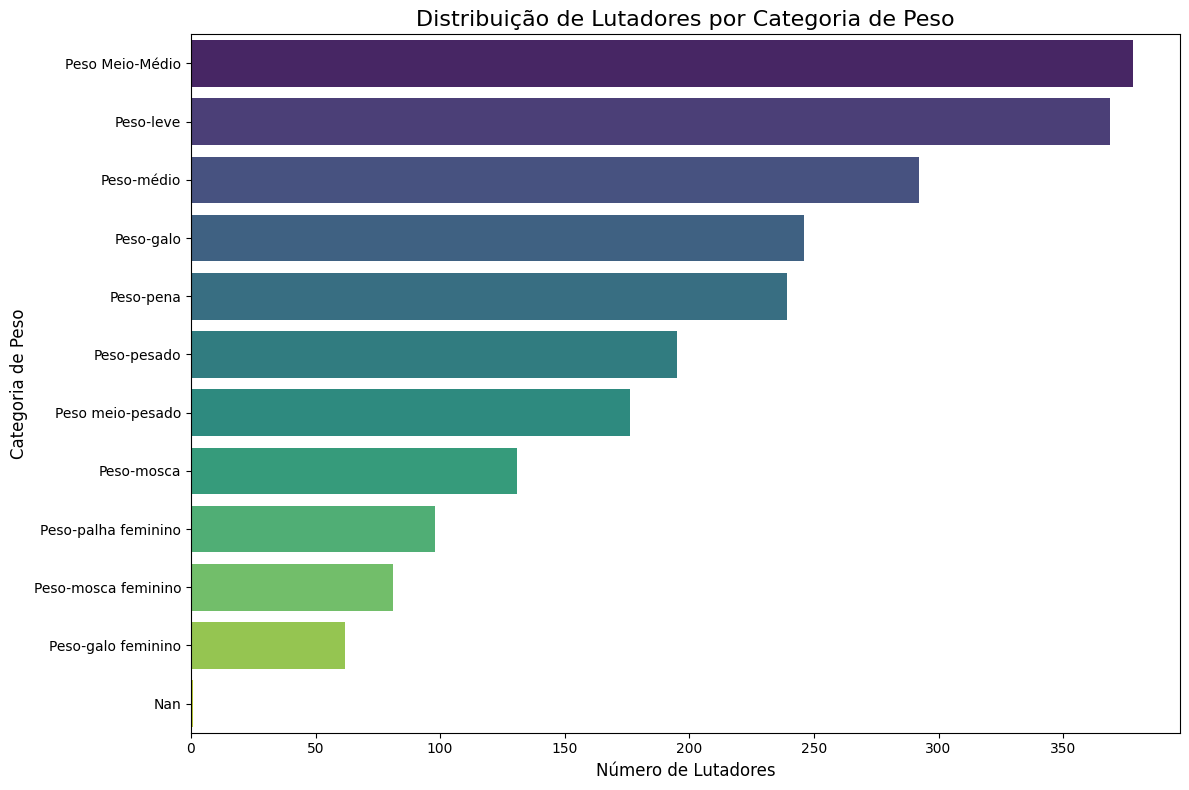

In [46]:
plt.figure(figsize=(12, 8))
sns.countplot(y=df['categoria'], order=df['categoria'].value_counts().index, palette='viridis')
plt.title('Distribuição de Lutadores por Categoria de Peso', fontsize=16)
plt.xlabel('Número de Lutadores', fontsize=12)
plt.ylabel('Categoria de Peso', fontsize=12)
plt.tight_layout()

#### **Resumo Geral:**

- Em uma análise simples, vemos que há mais lutadores de peso `Meio-Médio`, seguido de `Peso-leve` e `Peso-Médio`

- Portanto, também podemos concluir que no UFC há uma predominância de lutadores na faixa dos 70 a 84 kg, que correspondem as 3 primeiras categorias no ranking

#### **Acabamos de ver um exemplo simples de como podemos utilizar esses dados para enxergar insights valiosos. Agora, aumentaremos o nível de complexidade de nossas análises**

---

## **2ª Pergunta:**
### **Quais são os arquétipos existentes no UFC?**

#### Os arquétipos são os estilos de lutas existentes no cenário do UFC, nos quais iremos classificar, cada lutador, a partir das suas características de luta.

#### Para começar, temos que analisar quantos tipos de arquétipos existem, e para isso, utilizaremos a **técnica do cotovelo**, para encontrar a quantidade de arquétipos ideal, que será representada por "k"

In [47]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

- Importaremos ferramentas da biblioteca `scikit-learn`, que trabalha com agrupamentos (clusterização) e machine learning

In [48]:
df_cluster = df[
    (df['win'] > 3) &
    (df['lose'] >= 1) &
    (df['tempo_medio'] > 180) &
    (df['sexo_M'] == 1)
].copy()

features = [
    'precisao_striking', 'golpes_sig_conectados', 'golpes_sig_absorvidos',
    'defesa_golpes_sig', 'media_quedas', 'defesa_quedas',
    'media_knockdowns', 'media_fin','method_fin','method_ko_tko','sig_head_str','sig_clinch_str'
]
df_features = df_cluster[features].fillna(0)

- Limitamos esta análise para os lutadores com mais de 3 vitórias, 1 ou mais derrotas, e pelo menos 3 minutos de luta na carreira.

- Utilizamos, para descobrir nosso k, dados mais complexos dos atletas. Será utilizado as estatísticas de desempenho principais, os métodos de vitórias, e os dados de golpes principais.

In [49]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features)
inertia = []
K_range = range(2, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

- Testaremos o "k" para valores de 2 até 10 para analisarmos o gráfico do cotovelo

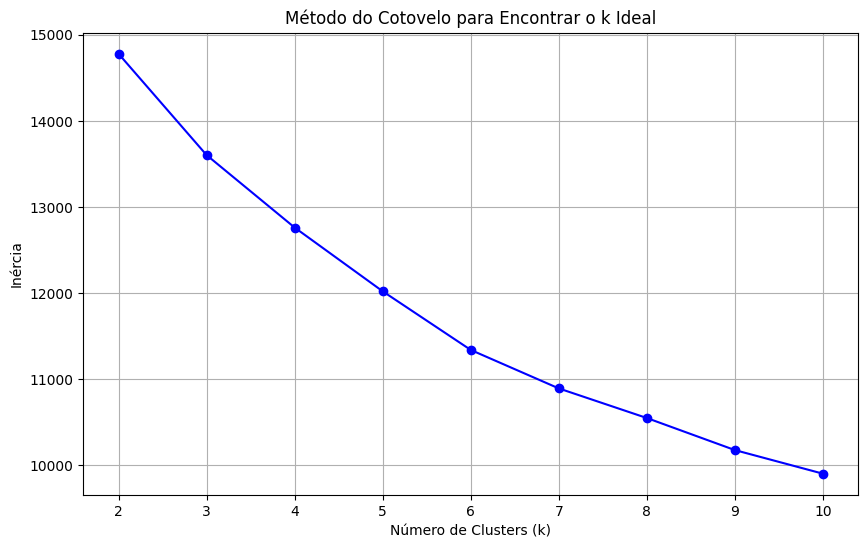

In [50]:
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, 'bo-')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inércia')
plt.title('Método do Cotovelo para Encontrar o k Ideal')
plt.grid(True)
plt.show()

- Pode-se concluir que o "cotovelo" está em 5, portanto existem **5 arquétipos principais**

#### Agora, vamos plotar um gráfico de agrupamento, através de uma predição de um modelo treinado para 5 arquétipos diferentes. 

In [51]:
optimal_k = 5

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
df_cluster['cluster'] = clusters

cluster_names = {
    0: 'Finalizadores',
    1: 'Lutadores Porteiros',
    2: 'Strikers Elite',
    3: 'Grapplers',
    4: 'Lutadores Versáteis',
}
df_cluster['arquetipo'] = df_cluster['cluster'].map(cluster_names)

- #### Categorizamos da seguinte forma:

    - ##### <span style="color: #f85b1dff;">Finalizadores:</span> especialistas em agarramento (grappling) ofensivo, que costumam vencer suas lutas por finalização (ex: mata-leão, chave de braço).

    - ##### <span style="color: #6bd1f1ff;">Lutadores Versáteis:</span> possuem habilidades equilibradas em várias áreas, tanto em pé quanto no chão, adaptando-se bem a diferentes estilos de luta.

    - ##### <span style="color: #ea0eedff;">Grapplers:</span> preferem a luta agarrada, buscando quedas e controle no solo, mas nem sempre finalizam as lutas.

    - ##### <span style="color: #5e81b2ff;">Strikers Elite:</span> têm grande destaque na trocação (golpes em pé), com técnicas de socos e chutes muito apuradas.

    - ##### <span style="color: #43e227ff;">Lutadores Porteiros:</span> geralmente servem como teste para atletas em ascensão, sendo experientes, mas sem participarem dos holofotes.

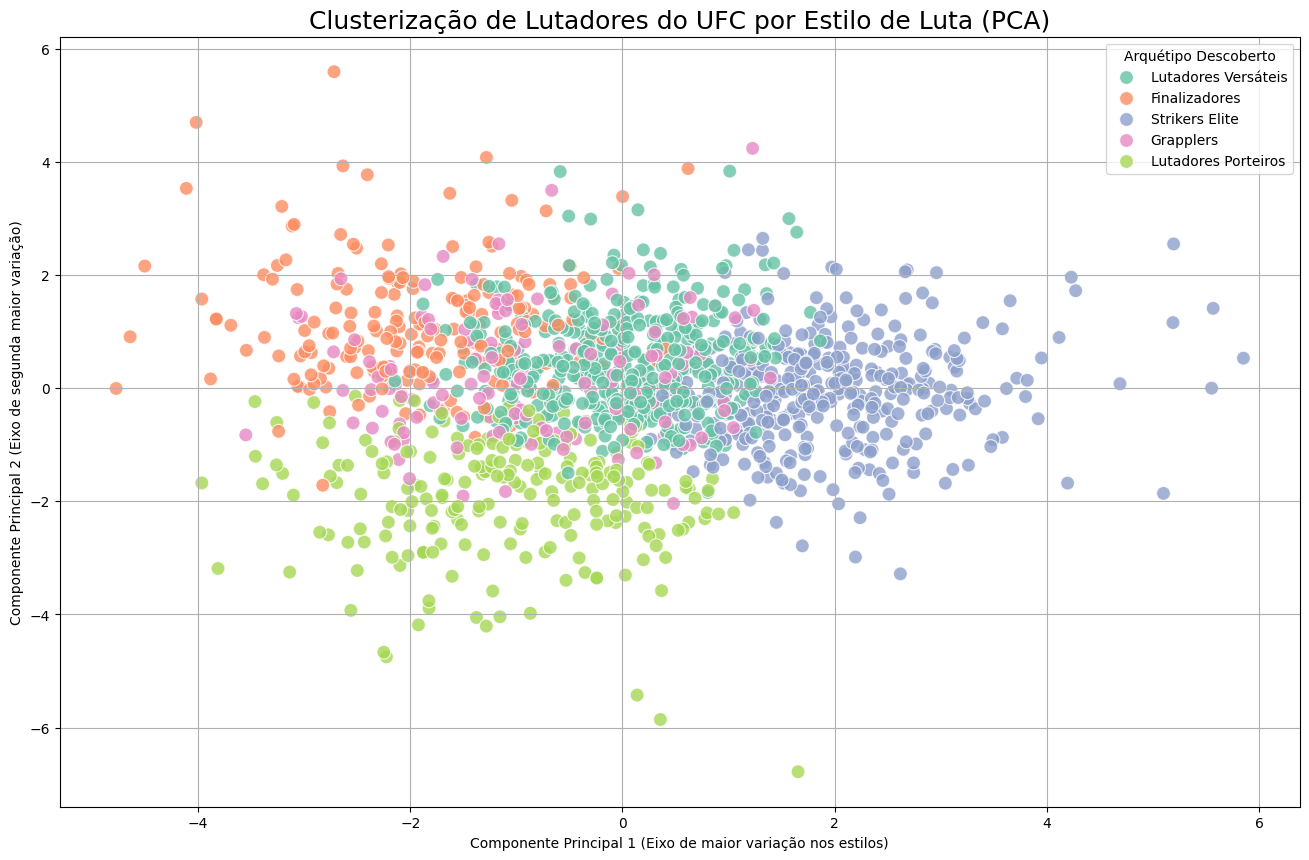

In [52]:
z_centroids = kmeans.cluster_centers_

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_cluster['pca1'] = X_pca[:, 0]
df_cluster['pca2'] = X_pca[:, 1]


plt.figure(figsize=(16, 10))
sns.scatterplot(
    data=df_cluster,x='pca1',y='pca2',hue='arquetipo',palette='Set2',s=100,alpha=0.8)
plt.title('Clusterização de Lutadores do UFC por Estilo de Luta (PCA)', fontsize=18)
plt.xlabel('Componente Principal 1 (Eixo de maior variação nos estilos)')
plt.ylabel('Componente Principal 2 (Eixo de segunda maior variação)')
plt.legend(title='Arquétipo Descoberto')
plt.grid(True)
plt.show()

- Podemos ver uma amostra dos arquétipos de cada lutador, sendo representados por pontinhos, porém o gráfico ainda está meio confuso para visualização

#### Portanto, iremos criar **gráficos de radar** para cada um dos arquétipos que o nosso modelo identificou

In [53]:
min_val = z_centroids.min()
max_val = z_centroids.max()
range_val = max_val - min_val
centroids_normalized = (z_centroids - min_val) / range_val

mean_line_position = (0 - min_val) / range_val

- Para começar, normalizamos os dados para que todas as variáveis estejam na mesma escala, achatando tudo para que fique em um intervalo entre 0 e 1

- Também posicionaremos uma linha média, transformando o valor 0 (que representa a média no z-score) na nova escala normalizada. A linha irá nos mostrar valores abaixo e acima da média

In [54]:
import numpy as np

In [55]:
labels_radar = [
    'Precisão\nStriking', 'Golpes Sig.\nConectados', 'Golpes Sig.\nAbsorvidos',
    'Defesa\nGolpes Sig.', 'Média\nQuedas', 'Defesa\nQuedas',
    'Média\nKnockdowns', 'Média\nFinalizações', 'Finalizações\nTécnicas',
    'Nocautes\nTKO', 'Golpes\nCabeça', 'Golpes\nClinch'
]

angles = np.linspace(0, 2 * np.pi, len(labels_radar), endpoint=False).tolist()
angles += angles[:1] 

- Criamos o template de cada gráfico e colocamos os eixos que estarão em cada um

- Plotaremos os gráficos por meio de um loop, que irá colocar os valores de cada eixo nos 5 arquétipos.

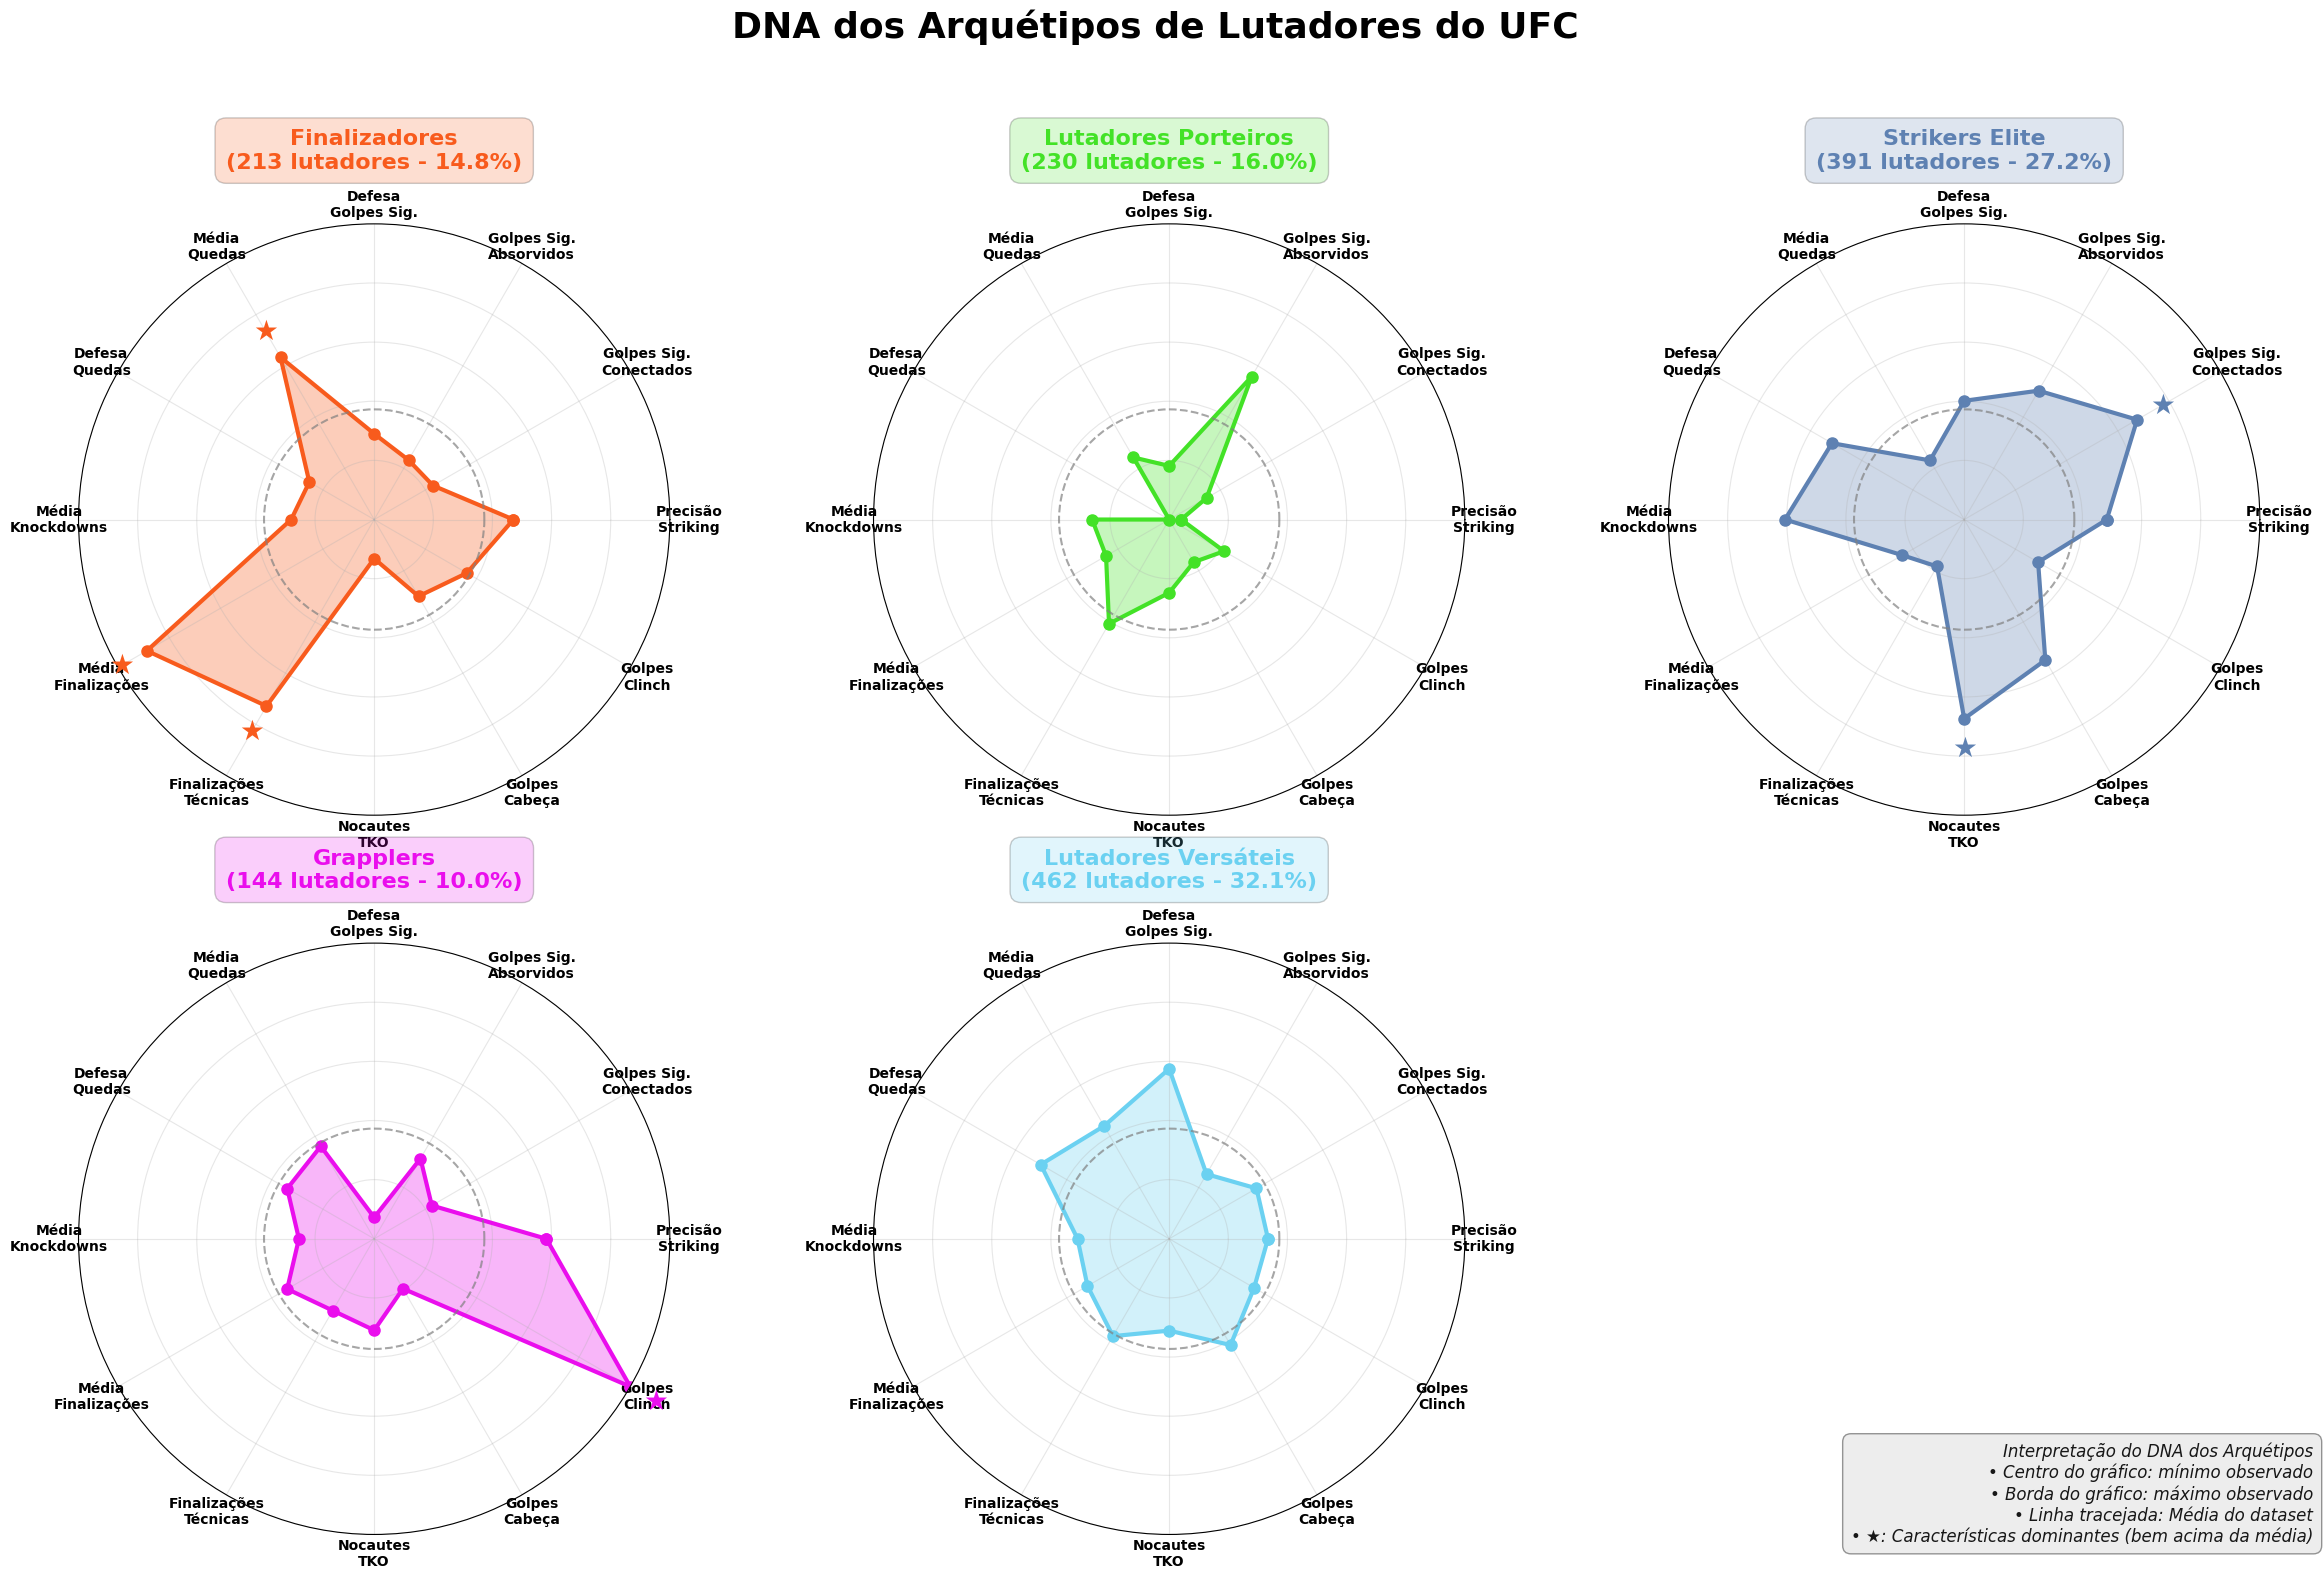

In [56]:
fig, axes = plt.subplots(figsize=(24, 16), nrows=2, ncols=3, subplot_kw=dict(polar=True))
fig.suptitle('DNA dos Arquétipos de Lutadores do UFC ', fontsize=26, fontweight='bold', y=0.98)
axes_flat = axes.flatten()

colors = ["#f85b1dff", '#43e227ff', '#5e81b2ff', '#ea0eedff', '#6bd1f1ff']

for i, ax in enumerate(axes_flat):
    if i < optimal_k:
        values = centroids_normalized[i].tolist()
        values += values[:1]

        ax.plot(angles, values, color=colors[i], linewidth=3, linestyle='solid', marker='o', markersize=8)
        ax.fill(angles, values, color=colors[i], alpha=0.3)

        ax.set_thetagrids(np.degrees(angles[:-1]), labels_radar, fontsize=10, fontweight='bold')
        ax.set_ylim(0, 1)
        ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
        ax.set_yticklabels(['', '', '', '', ''], fontsize=9, alpha=0.7)
        ax.grid(True, alpha=0.3)

        cluster_size = len(df_cluster[df_cluster['cluster'] == i])
        cluster_pct = cluster_size / len(df_cluster) * 100
        title_text = f"{cluster_names[i]}\n({cluster_size} lutadores - {cluster_pct:.1f}%)"
        ax.set_title(title_text, size=16, color=colors[i], y=1.08, fontweight='bold',
                      bbox=dict(boxstyle="round,pad=0.5", facecolor=colors[i], alpha=0.2))
        
        ax.axhline(y=mean_line_position, color='gray', linestyle='--', alpha=0.7, linewidth=1.5)

        for j, (angle, value) in enumerate(zip(angles[:-1], values[:-1])):
            if value > mean_line_position + 0.25:
                ax.annotate('★', xy=(angle, value), xytext=(angle, value + 0.1),
                            fontsize=20, color=colors[i], ha='center', va='center', fontweight='bold')

    else:
        ax.set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.94])

legend_text = (
    'Interpretação do DNA dos Arquétipos\n'
    '• Centro do gráfico: mínimo observado\n'
    '• Borda do gráfico: máximo observado\n'
    '• Linha tracejada: Média do dataset\n'
    '• ★: Características dominantes (bem acima da média)'
)

plt.figtext(0.98, 0.02, legend_text, fontsize=12, style='italic', alpha=0.9,
            bbox=dict(boxstyle="round,pad=0.5", facecolor='lightgray', alpha=0.4),
            ha='right', va='bottom')

plt.show()

- Agora podemos ver melhor as características de cada arquétipo e seus atributos. Podemos analisar em que atributos cada arquétipo se destaca.
    
    - Os <span style="color: #f85b1dff;">finalizadores </span>se destacam nas `Média de Finalizações`, `Média de Quedas`, e nas `Finalizações Técnicas`

    - Já os <span style="color: #6bd1f1ff;"> lutadores versáteis </span>, que tem o maior número de lutadores, acertam mais `Golpes na Cabeça`, e utilizam de técnicas variadas

    - <span style="color: #ea0eedff;">Grapplers </span>focam mais em `Golpes Clinch`, que são golpes corpo a corpo

    - Vemos que os <span style="color: #5e81b2ff;">strikers de elite </span>são excepcionais em `Nocautes TKO`, alta `Média de Knockdowns`, e tem mais `Golpes Sig. Conectados`. Eles representam a minoria dos lutadores, mas são muito eficazes

    - E os <span style="color: #43e227ff;">lutadores porteiros </span>são lutadores mais casuais, não se destacam em nada, e não possuem um estilo definido

#### Podemos também criar uma função simples, que consultará o arquétipo de um lutador específico que vamos querer

In [57]:
def verificar_arquetipo():
    nome_lutador = input("Lutador: ").strip()
    
    if 'nome_lutador' not in df_cluster.columns:
        df_cluster['nome_lutador'] = df.loc[df_cluster.index]['nome_lutador']

    lutador = df_cluster[df_cluster['nome_lutador'].str.contains(nome_lutador, case=False)]
    
    if not lutador.empty:
        nome_completo = lutador.iloc[0]['nome_lutador']
        estilo = lutador.iloc[0]['arquetipo']
        print(f"O arquétipo de '{nome_completo}' é: {estilo}")
    else:
        print(f"Lutador '{nome_lutador}' não encontrado no dataset clusterizado.")
        print("Isso pode ocorrer se o lutador não atendeu aos critérios de filtro (mínimo de vitórias, lutas, etc.).")

verificar_arquetipo()

O arquétipo de 'alex pereira' é: Strikers Elite


#### **Resumo Geral**:

- Existem **5 arquétipos principais** no UFC, e cada um deles tem suas características específicas, que se destacam em diferentes aspectos do combate.

- Podemos prever o arquétipo de um lutador a partir de suas estatísticas, o que pode ajudar a entender seu estilo de luta e estratégias.


---

## **3ª Pergunta:**
### **Quais são os arquétipos ideais para cada categoria de peso??**

#### Agora que já sabemos quais são os arquétipos, iremos analisar em quais categorias de peso eles se destacam mais
#### Iremos criar um **treemap** com todas as categorias de peso, e dentro de cada categoria, outro treemap com os arquétipos e suas médias de vitórias na categoria, para que fique explícito quais são os melhores e os piores arquétipos para cada peso

In [58]:
import plotly.express as px
from IPython.display import Image

- Utilizaremos a biblioteca `plotly`, que criar o treemap de forma simples e rápida, e o `kaleido`, que nos ajudará a salvar o gráfico em PNG

- Começamos filtrando o dataset para manter apenas as categorias de peso mais comuns, que possuem mais lutadores
- Agrupamos os dados por categoria e arquétipo, contando o número de lutadores e calculando a taxa de vitória média de cada estilo em cada peso  

In [59]:
if 'nome_lutador' not in df_cluster.columns:
    df_cluster['nome_lutador'] = df.loc[df_cluster.index]['nome_lutador']

ranking_categorias_cluster = df_cluster['categoria'].value_counts()

principais_categorias = ranking_categorias_cluster.head(8).index.tolist()
df_cluster_principais = df_cluster[df_cluster['categoria'].isin(principais_categorias)].copy()

cluster_stats = df_cluster_principais.groupby(['categoria', 'arquetipo']).agg({'nome_lutador': 'count','win': 'sum','lose': 'sum',
'draw': 'sum','precisao_striking': 'mean','golpes_sig_conectados': 'mean'}).reset_index()

cluster_stats['total_lutas'] = cluster_stats['win'] + cluster_stats['lose'] + cluster_stats['draw']
cluster_stats['taxa_vitoria'] = cluster_stats['win'] / cluster_stats['total_lutas']
cluster_stats = cluster_stats.rename(columns={'nome_lutador': 'num_lutadores'})

- Em seguida, criamos o **treemap** usando Plotly, onde o tamanho de cada bloco representa a quantidade de lutadores de cada arquétipo na categoria, e a cor indica a taxa de vitórias média daquele arquétipo naquele peso
- Iremos salvar a imagem do gráfico em um arquivo PNG nomeado como `"grafico_treemap.png"`
- Assim, conseguimos visualizar rapidamente quais estilos de luta são mais comuns e mais eficientes em cada categoria do UFC, facilitando a identificação dos arquétipos dominantes e daqueles que têm melhor desempenho em cada divisão

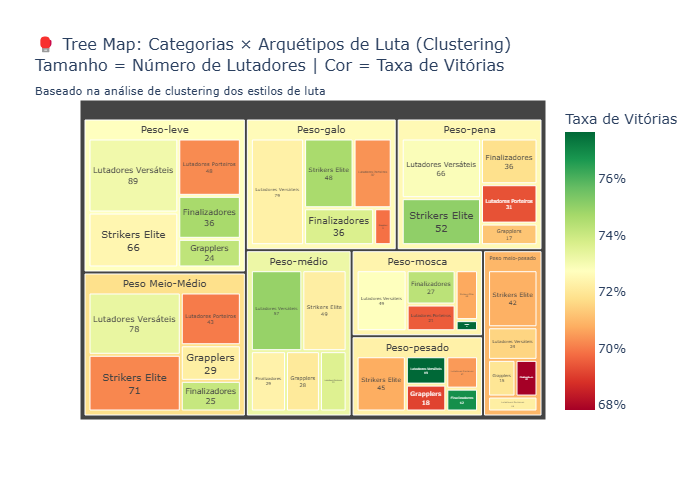

In [60]:
fig_cluster = px.treemap(cluster_stats,path=['categoria', 'arquetipo'],values='num_lutadores',color='taxa_vitoria',color_continuous_scale='RdYlGn',
    title='🥊 Tree Map: Categorias × Arquétipos de Luta (Clustering)<br>' +'Tamanho = Número de Lutadores | Cor = Taxa de Vitórias<br>' +'<sub>Baseado na análise de clustering dos estilos de luta</sub>',
    labels={'categoria': 'Categoria', 'arquetipo': 'Arquétipo','num_lutadores': 'Lutadores','taxa_vitoria': 'Taxa de Vitórias'}
)

fig_cluster.update_traces(
    textinfo="label+value",textfont_size=10,textposition="middle center",
    hovertemplate='<b>%{label}</b><br>'+'Lutadores: %{value}<br>' +'Taxa de Vitórias: %{color:.2%}<br>' +'<extra></extra>')

fig_cluster.update_layout(font_size=12,height=700,title_font_size=16,
    coloraxis_colorbar=dict(title="Taxa de Vitórias",tickformat=".0%")
)

fig_cluster.write_image("grafico_treemap.png")

Image(filename="grafico_treemap.png")

# fig_cluster.show()

#### A partir do gráfico, podemos tirar algumas conclusões interessantes:

- **Peso Mosca:** Os Finalizadores e os Lutadores Porteiros dominam a categoria em número de lutadores, mas os <span style="color: #0eed21ff;">Grapplers</span> são mais bem sucedidos. Então a luta no chão é mais eficaz nessa categoria

- **Peso Galo:** Os <span style="color: #0eed21ff;">Strikers</span> são os mais vitoriosos, e os <span style="color: #c70303ff;">Grapplers</span> são os que menos vencem. Portanto, analisa-se que a luta em pé é melhor

- **Peso Pena:** <span style="color: #0eed21ff;">Strikers</span> são os que mais vencem, e os <span style="color: #c70303ff;">Porteiros</span> são os que menos vencem, portanto existe uma elite de lutadores que se destacam na categoria

- **Peso Leve:** <span style="color: #0eed21ff;">Finalizadores</span> e <span style="color: #0eed21ff;">Grapplers</span> são os mais favorecidos, então ataques corpo a corpo são mais eficazes

- **Peso Meio-Médio:** Nessa categoria, os <span style="color: #0eed21ff;">Finalizadores</span> e os <span style="color: #0eed21ff;">Versáteis</span> são os mais vitoriosos, e os <span style="color: #c70303ff;">Porteiros</span> comumente são os que menos vencem. Portanto, nessa categoria, atacar no solo geralmente se mostra mais vantajoso

- **Peso Médio:** Vemos que os <span style="color: #0eed21ff;">Versáteis</span> são os melhores da categoria, mas essa categoria se mostra bastante equilibrada

- **Peso Meio-Pesado:** Nessa categoria, também observamos que a quantidade de lutadores e a taxa de vitórias dessa categoria, comparado com outras, é abaixo da média, indicando que é uma categoria mais equilibrada, com sua maioria sendo os strikers

- **Peso Pesado:** Os <span style="color: #0eed21ff;">Finalizadores</span> e os <span style="color: #0eed21ff;">Versáteis</span> são os melhores da categoria, e os <span style="color: #c70303ff;">Grapplers</span> são os que menos vencem, mostrando que a luta agarrada e intensa é mais segura do que uma estratégia no chão

#### **Resumo geral:**
- Arquétipos mais "puros" (Striker ou Grappler) tendem a se destacar em categorias mais leves e pesadas, enquanto os Versáteis e Finalizadores têm vantagem nas categorias intermediárias.

- O número de lutadores de cada arquétipo não necessariamente reflete o sucesso: há estilos menos comuns que são mais eficientes em determinadas divisões.

- O treemap facilita a visualização de quais estilos são mais comuns e mais eficazes em cada categoria, permitindo identificar tendências estratégicas do UFC por peso.


---

## **4ª Pergunta:**
### **As características físicas de um lutador influenciam na sua capacidade de defesa de quedas?**

#### Para responder essa pergunta, iremos analisar a relação entre as características físicas dos lutadores (altura e peso) e sua capacidade de defesa de quedas, que é uma estatística importante no MMA.
#### Vamos trabalhar com um modelo de regressão linear múltipla, que nos ajudará a entender como essas variáveis físicas influenciam a defesa de quedas.

In [61]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from scipy import stats

- Importaremos ferramentas da biblioteca `scikit-learn`, que trabalha com modelos de machine learning e regressão linear
- E também a biblioteca `scipy`, que nos ajudará a normalizar os dados

In [62]:
df_zscore = df.copy()

numeric_columns = df_zscore.select_dtypes(include=[np.number]).columns

for coluna in numeric_columns:
    df_zscore[coluna] = stats.zscore(df_zscore[coluna])
    
X_zscore = df_zscore[['altura_lutador', 'peso_lutador', 'idade_lutador']]
y_zscore = df_zscore['defesa_quedas']

X_train_z, X_test_z, y_train_z, y_test_z = train_test_split(
    X_zscore, y_zscore, test_size=0.2, random_state=42
)

- Normalizamos os dados numéricos do dataset utilizando o z-score, que padroniza os valores para terem média 0 e desvio padrão 1, facilitando a análise
- Separamos as variáveis independentes (altura, peso e idade) e a variável dependente (defesa de quedas)
- Dividimos os dados em conjuntos de treino (80%) e teste (20%) para avaliar o desempenho do modelo

In [63]:
modelo_zscore = LinearRegression()
modelo_zscore.fit(X_train_z, y_train_z)

y_pred_z = modelo_zscore.predict(X_test_z)

r2_zscore = modelo_zscore.score(X_test_z, y_test_z)
mse_zscore = mean_squared_error(y_test_z, y_pred_z)
rmse_zscore = np.sqrt(mse_zscore)

coeficientes_z = dict(zip(X_zscore.columns, modelo_zscore.coef_))

- Treinamos o modelo de regressão linear com os dados de treino e fazemos previsões com os dados de teste
- Calculamos métricas de desempenho como R², MSE (Erro Quadrático Médio) e RMSE (Raiz do Erro Quadrático Médio) para avaliar a precisão do modelo
- Agora plotamos um gráfico de dispersão comparando os valores reais de defesa de quedas com os valores previstos pelo modelo, para visualizarmos a precisão das previsões

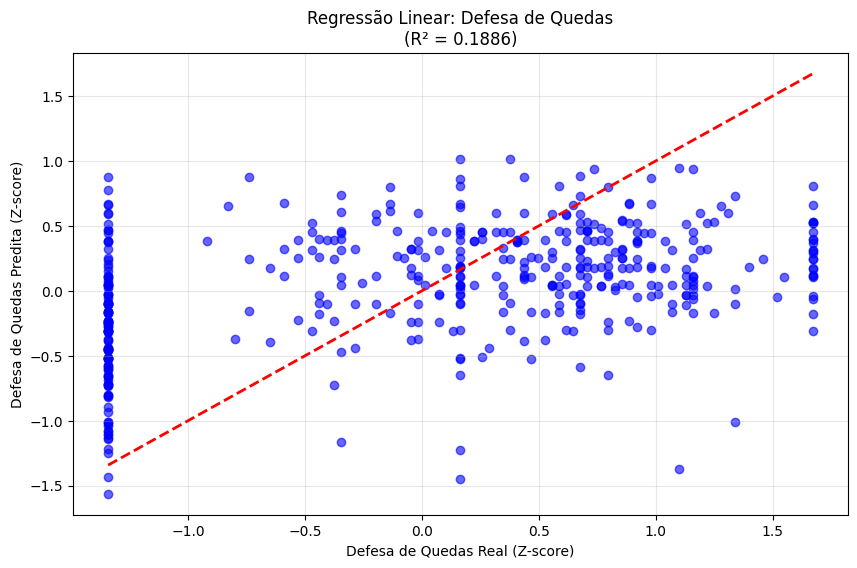

In [64]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test_z, y_pred_z, alpha=0.6, color='blue')
plt.plot([y_test_z.min(), y_test_z.max()], [y_test_z.min(), y_test_z.max()], 'r--', lw=2)
plt.xlabel('Defesa de Quedas Real (Z-score)')
plt.ylabel('Defesa de Quedas Predita (Z-score)')
plt.title(f'Regressão Linear: Defesa de Quedas\n(R² = {r2_zscore:.4f})')
plt.grid(True, alpha=0.3)
plt.show()

#### Opa! Parece que o modelo não conseguiu capturar bem a relação entre as características físicas e a defesa de quedas

#### **Resumo geral**:

- Nossa análise de regressão demonstrou que, ao contrário do que se poderia supor, atributos físicos como altura, peso e idade não são bons preditores da habilidade de um lutador em defender quedas.

- Isso reforça a ideia de que a defesa de quedas é uma habilidade predominantemente técnica, dependente de treino e tempo de reação, e não de fatores físicos inatos.

---

## **5ª Pergunta:**
### Quais são os arquétipos existentes no Women's UFC?

#### Agora iremos analisar o cenário atual das lutadoras no UFC, identificando os principais arquétipos que podemos encontrar.

- Iremos fazer o mesmo processo que fizemos para os homens, porém agora com as mulheres, começando com a **técnica do cotovelo** para descobrir quantos arquétipos existem

- Continuaremos utilizando as mesmas estatísticas de desempenho, métodos de vitória e dados de golpes principais

- Também utilizamos o mesmo filtro de lutadoras com mais de 3 vitórias, 1 ou mais derrotas, e pelo menos 3 minutos de luta na carreira



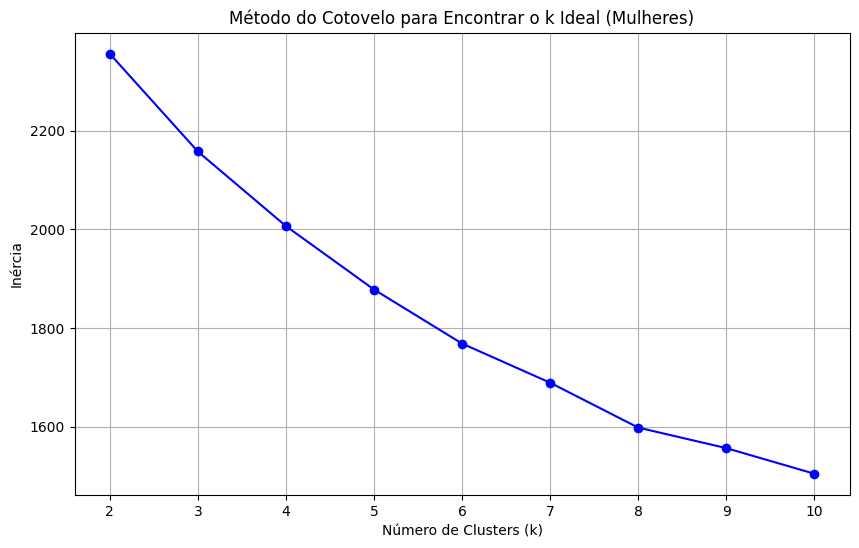

In [65]:
df_cluster = df[
    (df['win'] > 3) &
    (df['lose'] >= 1) &
    (df['tempo_medio'] > 180) &
    (df['sexo_F'] == 1)
].copy()

features = [
    'precisao_striking', 'golpes_sig_conectados', 'golpes_sig_absorvidos',
    'defesa_golpes_sig', 'media_quedas', 'defesa_quedas',
    'media_knockdowns', 'media_fin','method_fin','method_ko_tko','sig_head_str','sig_clinch_str'
]
df_features = df_cluster[features].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features)

inertia = []
K_range = range(2, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, 'bo-')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inércia')
plt.title('Método do Cotovelo para Encontrar o k Ideal (Mulheres)')
plt.grid(True)
plt.show()

- Vemos que o "cotovelo" ideal seria 5, por ter uma leve inclinação após esse ponto

- Isso nos indica que existem 5 arquétipos entre as lutadoras, assim como nos homens

#### Agora, vamos plotar o mesmo gráfico de clusterização, através de uma predição de um modelo treinado para os mesmos 5 arquétipos.

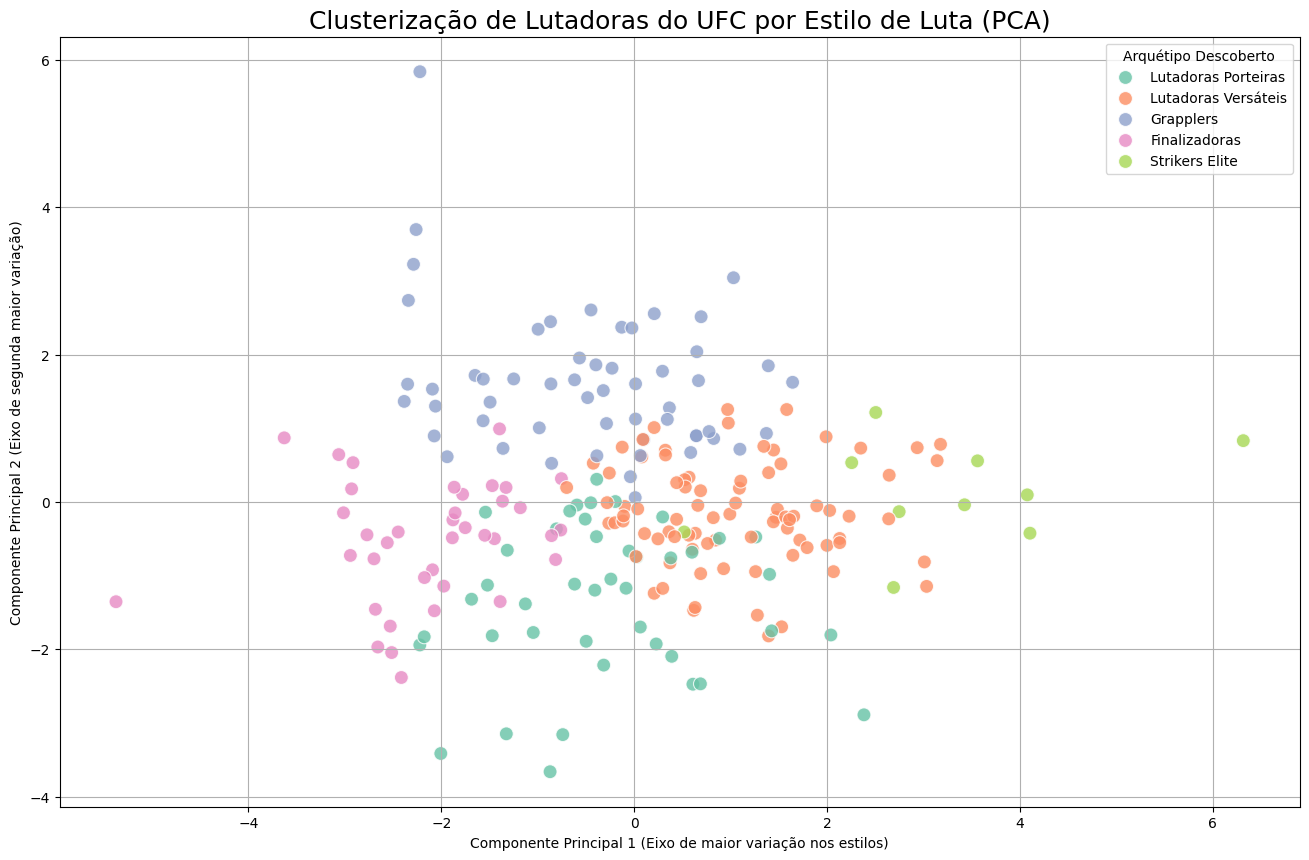

In [66]:
optimal_k = 5

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
df_cluster['cluster'] = clusters

cluster_names = {
    0: 'Lutadoras Versáteis',
    1: 'Lutadoras Porteiras',
    2: 'Grapplers',
    3: 'Strikers Elite',
    4: 'Finalizadoras'
}
df_cluster['arquetipo'] = df_cluster['cluster'].map(cluster_names)

z_centroids = kmeans.cluster_centers_

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_cluster['pca1'] = X_pca[:, 0]
df_cluster['pca2'] = X_pca[:, 1]


plt.figure(figsize=(16, 10))
sns.scatterplot(
    data=df_cluster,x='pca1',y='pca2',hue='arquetipo',palette='Set2',s=100,alpha=0.8)
plt.title('Clusterização de Lutadoras do UFC por Estilo de Luta (PCA)', fontsize=18)
plt.xlabel('Componente Principal 1 (Eixo de maior variação nos estilos)')
plt.ylabel('Componente Principal 2 (Eixo de segunda maior variação)')
plt.legend(title='Arquétipo Descoberto')
plt.grid(True)
plt.show()

- Enfrentamos o mesmo desafio que tivemos com os homens, o gráfico ficou muito confuso, mesmo reduzindo a quantidade de informações, então iremos criar os gráficos de radar para cada arquétipo

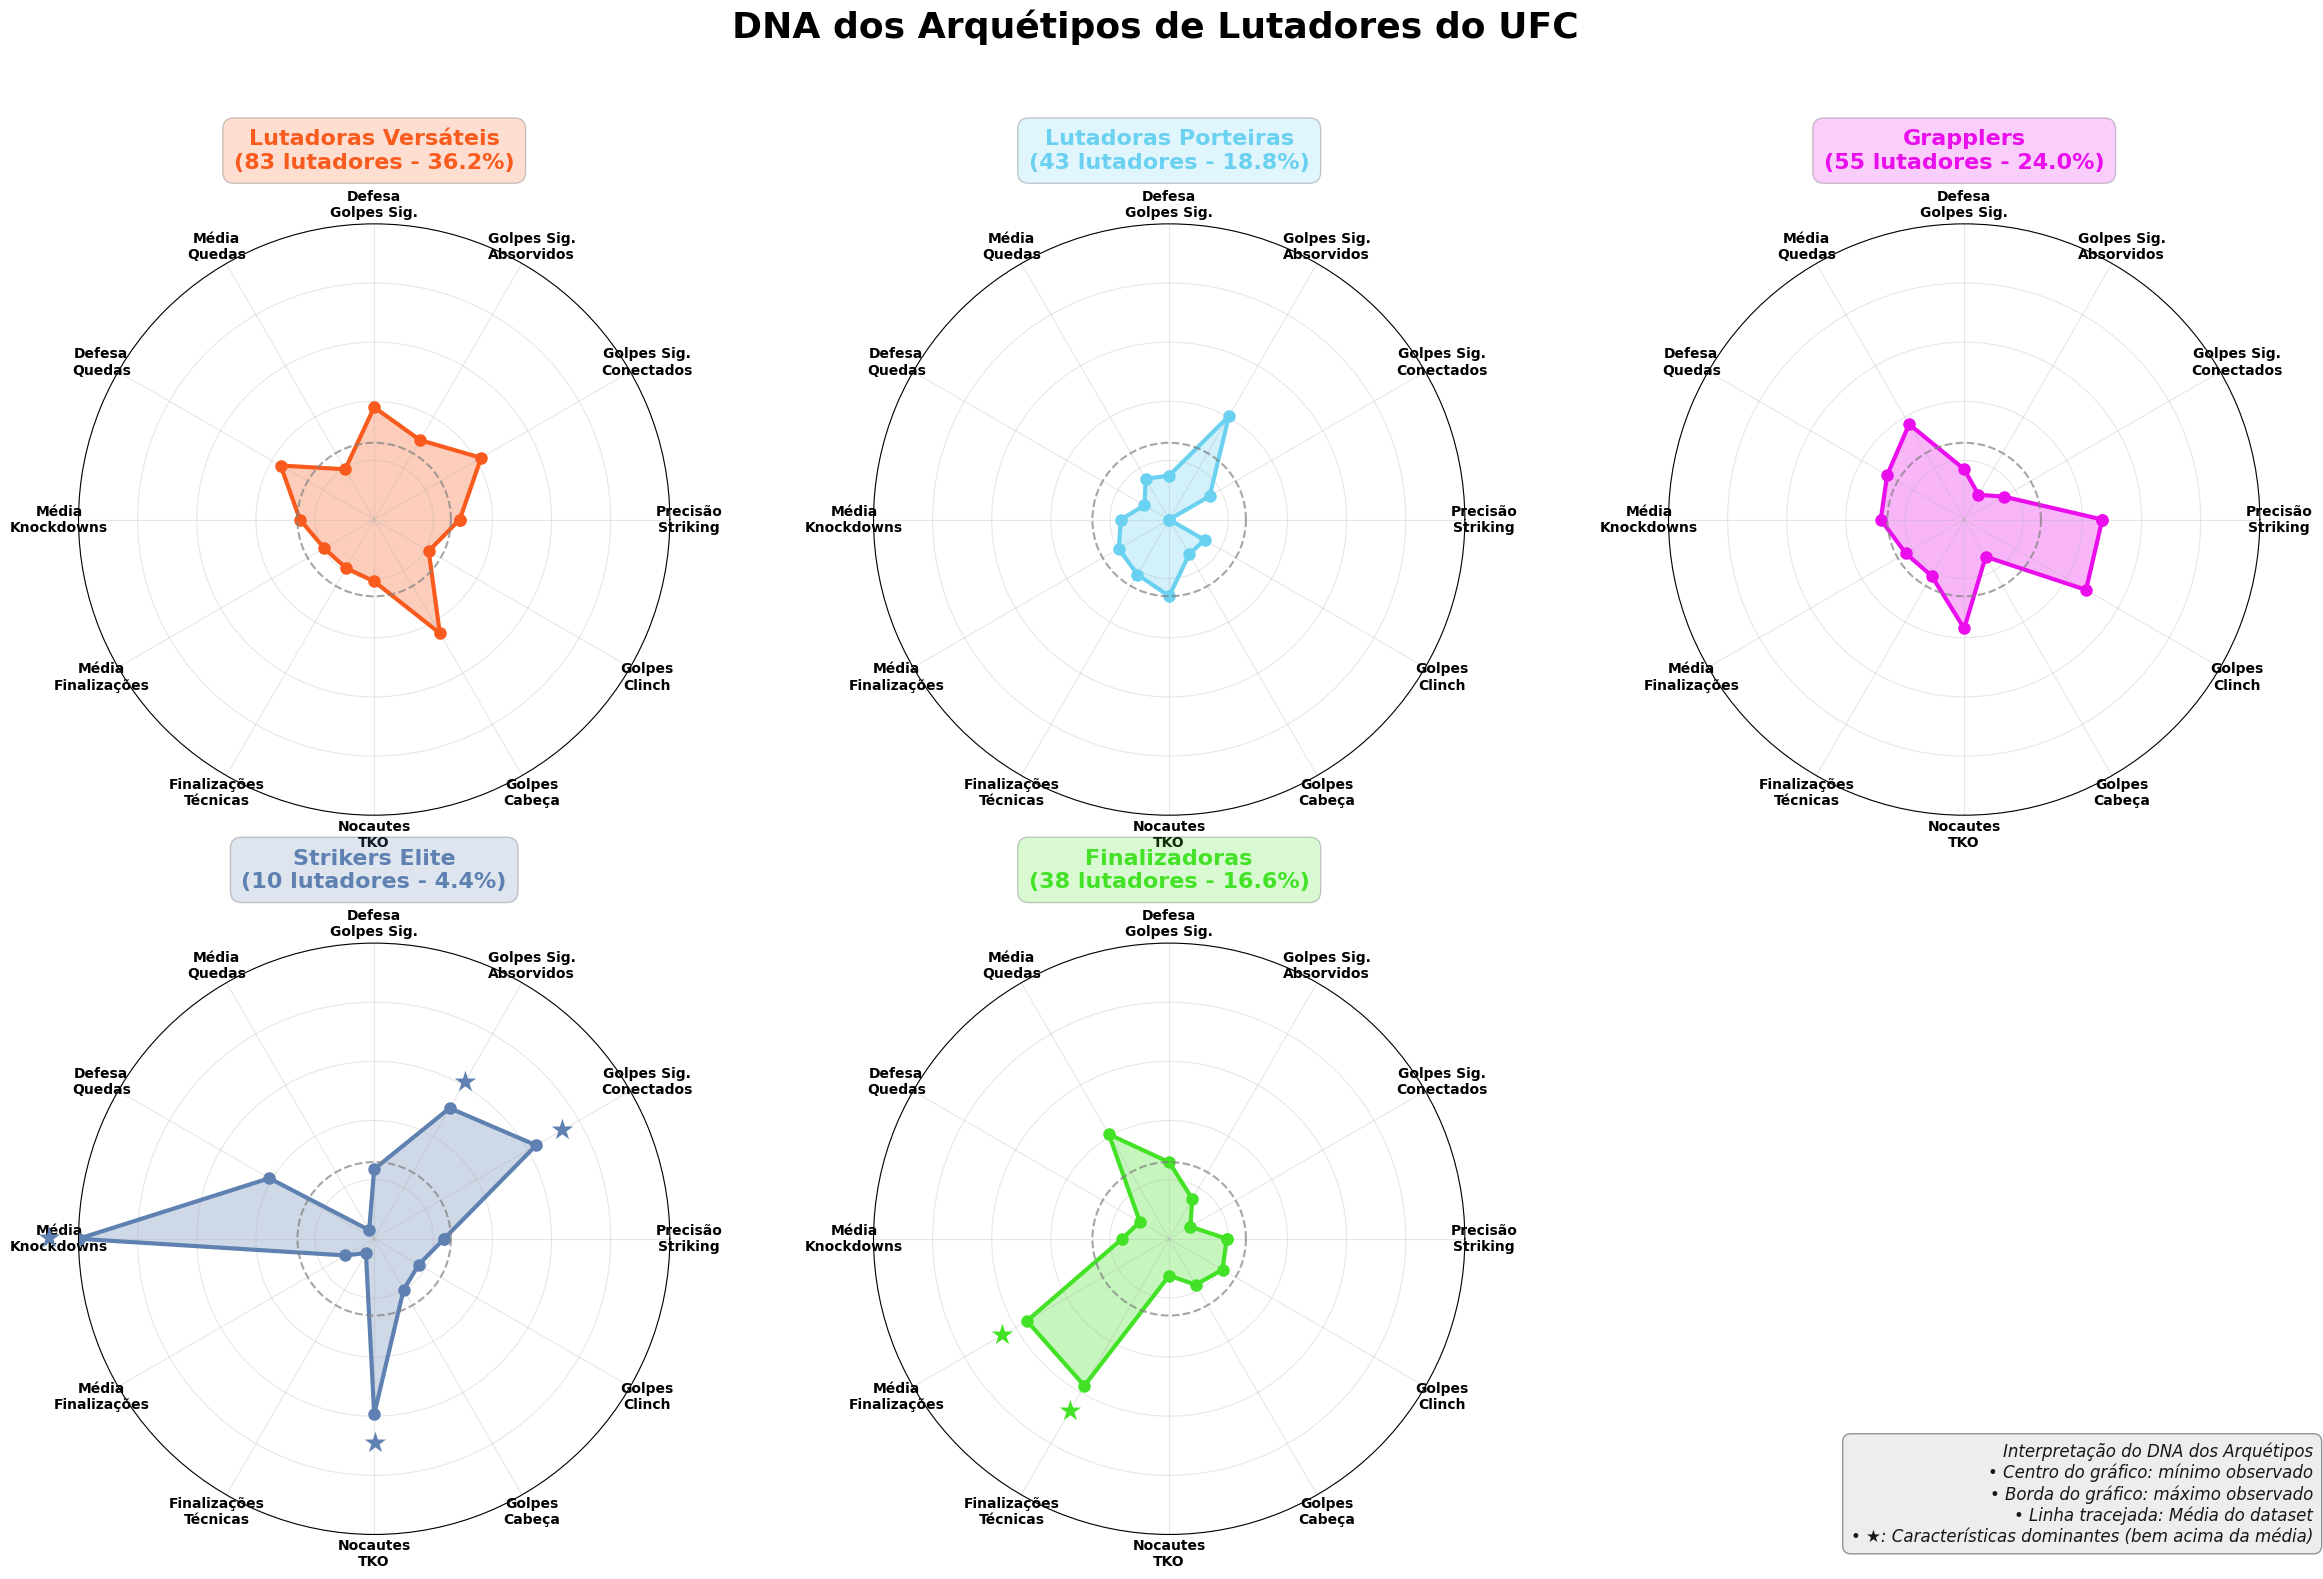

In [67]:
min_val = z_centroids.min()
max_val = z_centroids.max()
range_val = max_val - min_val
centroids_normalized = (z_centroids - min_val) / range_val


mean_line_position = (0 - min_val) / range_val


labels_radar = [
    'Precisão\nStriking', 'Golpes Sig.\nConectados', 'Golpes Sig.\nAbsorvidos',
    'Defesa\nGolpes Sig.', 'Média\nQuedas', 'Defesa\nQuedas',
    'Média\nKnockdowns', 'Média\nFinalizações', 'Finalizações\nTécnicas',
    'Nocautes\nTKO', 'Golpes\nCabeça', 'Golpes\nClinch'
]

angles = np.linspace(0, 2 * np.pi, len(labels_radar), endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(figsize=(24, 16), nrows=2, ncols=3, subplot_kw=dict(polar=True))
fig.suptitle('DNA dos Arquétipos de Lutadores do UFC ', fontsize=26, fontweight='bold', y=0.98)
axes_flat = axes.flatten()

colors = ['#f85b1dff', '#6bd1f1ff', '#ea0eedff', '#5e81b2ff', '#43e227ff']

for i, ax in enumerate(axes_flat):
    if i < optimal_k:
        values = centroids_normalized[i].tolist()
        values += values[:1]

        ax.plot(angles, values, color=colors[i], linewidth=3, linestyle='solid', marker='o', markersize=8)
        ax.fill(angles, values, color=colors[i], alpha=0.3)

        ax.set_thetagrids(np.degrees(angles[:-1]), labels_radar, fontsize=10, fontweight='bold')
        ax.set_ylim(0, 1)
        ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
        ax.set_yticklabels(['', '', '', '', ''], fontsize=9, alpha=0.7)
        ax.grid(True, alpha=0.3)

        cluster_size = len(df_cluster[df_cluster['cluster'] == i])
        cluster_pct = cluster_size / len(df_cluster) * 100
        title_text = f"{cluster_names[i]}\n({cluster_size} lutadores - {cluster_pct:.1f}%)"
        ax.set_title(title_text, size=16, color=colors[i], y=1.08, fontweight='bold',
                      bbox=dict(boxstyle="round,pad=0.5", facecolor=colors[i], alpha=0.2))
        
        # Adiciona a linha da média (Z-score = 0)
        ax.axhline(y=mean_line_position, color='gray', linestyle='--', alpha=0.7, linewidth=1.5)

        for j, (angle, value) in enumerate(zip(angles[:-1], values[:-1])):
            if value > mean_line_position + 0.25:
                ax.annotate('★', xy=(angle, value), xytext=(angle, value + 0.1),
                            fontsize=20, color=colors[i], ha='center', va='center', fontweight='bold')

    else:
        ax.set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.94])

legend_text = (
    'Interpretação do DNA dos Arquétipos\n'
    '• Centro do gráfico: mínimo observado\n'
    '• Borda do gráfico: máximo observado\n'
    '• Linha tracejada: Média do dataset\n'
    '• ★: Características dominantes (bem acima da média)'
)

plt.figtext(0.98, 0.02, legend_text, fontsize=12, style='italic', alpha=0.9,
            bbox=dict(boxstyle="round,pad=0.5", facecolor='lightgray', alpha=0.4),
            ha='right', va='bottom')

plt.show()

- Vamos analisar os gráficos de radar, agora para o Women's UFC
    
    - As <span style="color: #f85b1dff;">finalizadoras </span>se destacam nas `Média de Finalizações`, e nas `Finalizações Técnicas`, assim como os homens, característico desse estilo

    - Já as <span style="color: #6bd1f1ff;"> versáteis </span>, que também tem mais lutadoras, acertam mais `Golpes na Cabeça`, e mesclam técnicas variadas em suas lutas

    - Temos que as <span style="color: #ea0eedff;">Grapplers </span> utilizam também de `Golpes Clinch`, que são golpes corpo a corpo em direção ao solo. Além disso se destacam em `precisão striking`

    - Impressionante! As <span style="color: #5e81b2ff;">strikers de elite </span>são completamente fora da curva. Muitos `Nocautes TKO`, altíssima `Média de Knockdowns`, e conectam bem mais golpes mas também absorvem mais contato, mostrando que são agressivas e eficientes. Só são registradas 10 strikers, mas as 10 são suficientes para mostrar que são excepcionais

    - E as <span style="color: #43e227ff;">lutadoras porteiras </span>são lutadoras mais casuais, não se destacam em nada, e não possuem um estilo definido (inclusive, são as que mais apanham)

#### Reuniremos aqui também os arquétipos de cada lutadora em atividade que desejamos consultar.

In [68]:
def verificar_arquetipo():
    nome_lutadora = input("Lutadora: ").strip()
    
    if 'nome_lutador' not in df_cluster.columns:
        df_cluster['nome_lutador'] = df.loc[df_cluster.index]['nome_lutador']

    lutadora = df_cluster[df_cluster['nome_lutador'].str.contains(nome_lutadora, case=False)]

    if not lutadora.empty:
        nome_completo = lutadora.iloc[0]['nome_lutador']
        estilo = lutadora.iloc[0]['arquetipo']
        print(f"O arquétipo da '{nome_completo}' é: {estilo}")
    else:
        print(f"Lutadora '{nome_lutadora}' não encontrada no dataset clusterizado.")
        print("Isso pode ocorrer se a lutadora não atendeu aos critérios de filtro (mínimo de vitórias, lutas, etc.).")

verificar_arquetipo()

O arquétipo da 'maria oliveira' é: Lutadoras Porteiras


#### **Resumo Geral:**

- Assim como no cenário masculino, existem **5 arquétipos principais** no Women's UFC, e cada um deles tem suas características específicas, que se destacam em diferentes aspectos do combate.

- Podemos prever o arquétipo de uma lutadora a partir de suas estatísticas, o que pode ajudar a entender seu estilo de luta e estratégias.

---

## **<span style="color: #5ef68eff;">✅Conclusão</span>**

- ##### Na **1ª análise**, vimos que a categoria de peso com mais lutadores é a de Meio-Médio, seguida por Peso-Leve e Peso-Médio, que correspondem as faixas de peso entre 70 a 84 kg. Também tivemos o primeiro contato com os dados, e vimos como podemos extrair insights valiosos a partir deles.

- ##### Na **2ª** e na **5ª análise**, os arquétipos dos lutadores e lutadoras revelaram padrões interessantes em seu estilo de luta e desempenho. Compreender esses arquétipos pode ajudar treinadores e lutadores a aprimorar suas estratégias e abordagens no octógono.

- ##### Na **3ª análise**, analisamos os arquétipos ideais para cada categoria de peso, e vimos que arquétipos mais "puros" (Striker ou Grappler) tendem a se destacar em categorias mais leves, enquanto os Versáteis e Finalizadores têm vantagem nas categorias mais pesadas. Também vimos que o número de lutadores de cada arquétipo não necessariamente reflete o sucesso: há estilos menos comuns que são mais eficientes em determinadas divisões.

- ##### E na **4ª análise**, o modelo de regressão linear não conseguiu capturar bem a correlação entre as características físicas e a defesa de quedas. Portanto, as características físicas e o desempenho na defesa de quedas não parecem ter uma relação direta e significativa no UFC, sugerindo que outros fatores são mais determinantes para essa habilidade.

#### Com base em todas as análises, podemos concluir que o UFC é um esporte complexo, onde diversos fatores influenciam o desempenho dos lutadores. A compreensão dos arquétipos e das estratégias ideais para cada categoria de peso pode ser uma ferramenta valiosa para treinadores e atletas que buscam aprimorar suas habilidades e alcançar o sucesso no octógono. 


---

## **<span style="color: #dc0457ff;">⛔Limitações</span>**

#### Apesar dos ótimos resultados, nosso projeto possui algumas limitações que podem ser abordadas em trabalhos futuros:

- ##### **Dados atuais** Nossos dados representam uma 'fotografia' do estado atual dos lutadores e não acompanham sua evolução ao longo da carreira. Isso pode limitar a capacidade de prever o desempenho futuro com base em tendências passadas.

- ##### **Dados incompletos**: O dataset utilizado pode não conter todas as informações relevantes sobre os lutadores, como histórico de lesões, mudanças de categoria de peso, ou detalhes sobre o treinamento e preparação física. Esses fatores podem influenciar significativamente o desempenho dos lutadores e a precisão das análises.

- ##### **Variabilidade do esporte**: O MMA é um esporte altamente dinâmico e imprevisível, onde fatores como sorte, decisões dos juízes, e circunstâncias específicas de cada luta podem afetar os resultados. Isso pode limitar a capacidade de modelos preditivos baseados apenas em estatísticas passadas.

## **<span style="color: #6d0388ff;">👣 Próximos Passos</span>**

#### Para superar essas limitações e aprofundar nossa compreensão do UFC, podemos explorar as seguintes direções para trabalhos futuros:

- ##### **Análise das lutas**: Realizar uma análise mais aprofundada das lutas, considerando fatores como estilo de luta, estratégias utilizadas e desempenho em diferentes situações e contextos. Dados como número de golpes desferidos em uma luta, precisão dos golpes na luta, tempo de luta, entre outros, podem ser utilizados para identificar padrões e tendências.

- ##### **Lutadores do Passado**: Investigar o desempenho e os estilos de luta de lutadores aposentados, a fim de identificar padrões e lições que podem ser aplicadas aos lutadores atuais, e comparar como o esporte evoluiu ao longo do tempo.

- ##### **Fatores externos**: Investigar como fatores externos, como condições de treinamento, lesões e preparação psicológica, podem influenciar o desempenho dos lutadores.

- ##### **Vendas e Marketing**: Analisar como as estratégias de vendas e marketing impactam a popularidade e o sucesso dos lutadores, incluindo a presença nas redes sociais e o engajamento com os fãs. Tendo em vista que o UFC é um esporte que depende muito da popularidade dos atletas para atrair público e patrocinadores.

---

## **<span style="color: #b5b4b4ff;">🔗Links Importantes:</span>**

- #### [GitHub do Projeto]()
- #### [Site do UFC](https://www.ufc.com.br/athletes)